In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Load dataset

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [3]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


Basic overview

In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   str    
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   str    
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   str    
 7   Urban_or_Rural                     9712 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 804.7 KB


,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


Check/handle missing,null values

In [5]:
df.isnull().sum() 
df['Health_Impacts'] = df['Health_Impacts'].fillna("Unknown")



In [6]:
df.describe(include=['object', 'string'])

,Gender,Primary_Device,Health_Impacts,Urban_or_Rural
count,9712,9712,9712,9712
unique,2,4,16,2
top,Male,Smartphone,Unknown,Urban
freq,4942,4568,3218,6851


In [7]:
df.describe(include='all')

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
count,9712.000000,9712,9712.000000,9712,9712,9712.000000,9712,9712
unique,NaN,2,NaN,4,2,NaN,16,2
top,NaN,Male,NaN,Smartphone,True,NaN,Unknown,Urban
freq,NaN,4942,NaN,4568,8301,NaN,3218,6851
mean,12.979201,NaN,4.352837,NaN,NaN,0.427226,NaN,NaN
std,3.162437,NaN,1.718232,NaN,NaN,0.073221,NaN,NaN
min,8.000000,NaN,0.000000,NaN,NaN,0.300000,NaN,NaN
25%,10.000000,NaN,3.410000,NaN,NaN,0.370000,NaN,NaN
50%,13.000000,NaN,4.440000,NaN,NaN,0.430000,NaN,NaN
75%,16.000000,NaN,5.380000,NaN,NaN,0.480000,NaN,NaN


Create Age Groups

In [8]:
df['Health_Impacts'].unique()

<ArrowStringArray>
[                       'Poor Sleep, Eye Strain',
                                    'Poor Sleep',
                                       'Unknown',
                           'Poor Sleep, Anxiety',
                      'Poor Sleep, Obesity Risk',
                                    'Eye Strain',
                                  'Obesity Risk',
                                       'Anxiety',
             'Poor Sleep, Anxiety, Obesity Risk',
                      'Eye Strain, Obesity Risk',
             'Eye Strain, Anxiety, Obesity Risk',
                         'Anxiety, Obesity Risk',
          'Poor Sleep, Eye Strain, Obesity Risk',
               'Poor Sleep, Eye Strain, Anxiety',
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
                           'Eye Strain, Anxiety']
Length: 16, dtype: str

In [9]:
bins = [0, 6, 10, 14, 18]
labels = ['0-6', '7-10', '11-14', '15-18']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [10]:
df[['Age', 'Age_Group']].head()


,Age,Age_Group
0,14,11-14
1,11,11-14
2,18,15-18
3,15,15-18
4,12,11-14


EDA Visualizations

1. Screen time distribution

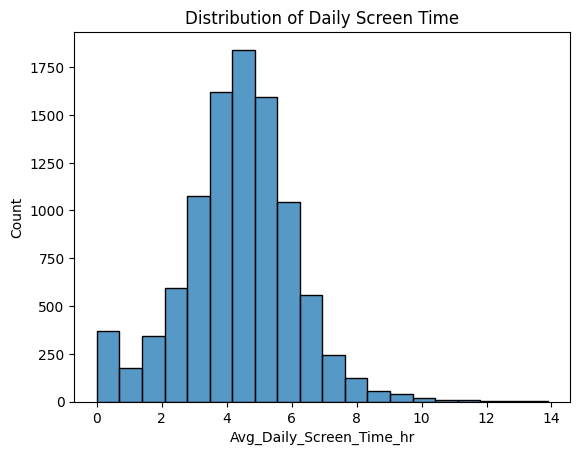

In [11]:
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20)
plt.title("Distribution of Daily Screen Time")
plt.show()


2. Screen time by gender

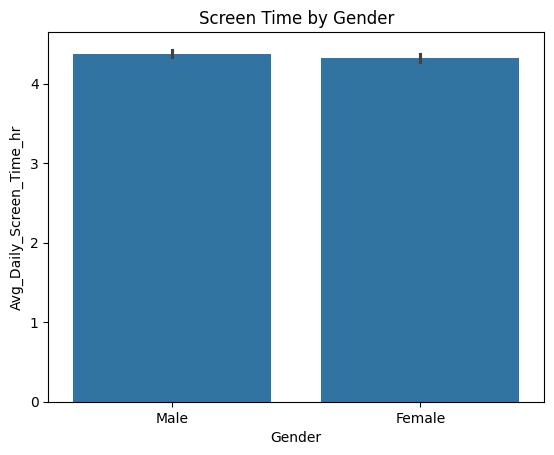

In [12]:
sns.barplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Gender")
plt.show()


3.Device usage

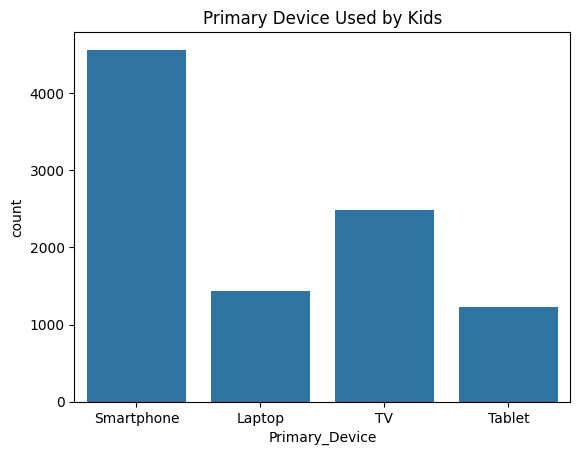

In [13]:
sns.countplot(x='Primary_Device', data=df)
plt.title("Primary Device Used by Kids")
plt.show()


4.Screen time by age group

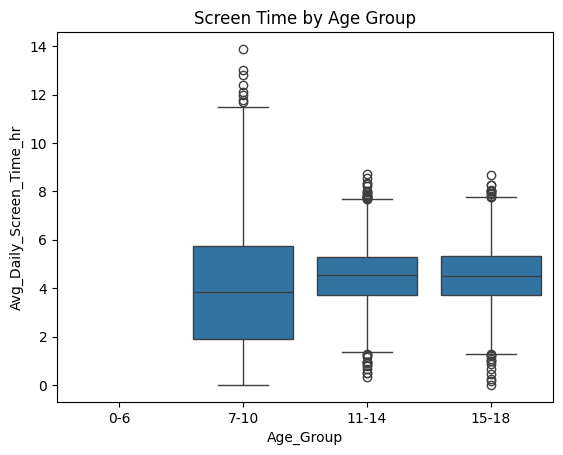

In [14]:
sns.boxplot(x='Age_Group', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Age Group")
plt.show()


5. Urban vs Rural screen time

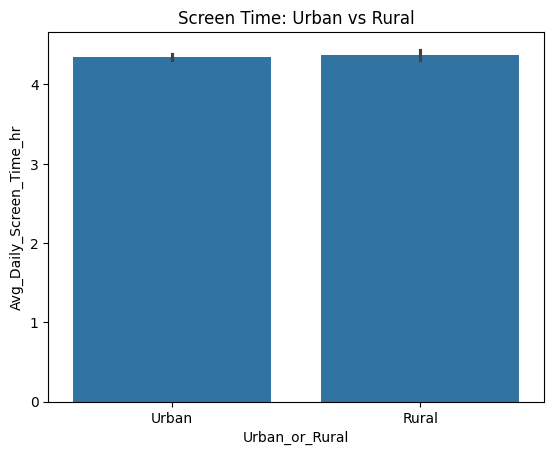

In [15]:
sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time: Urban vs Rural")
plt.show()


6. Exceeded recommended limit

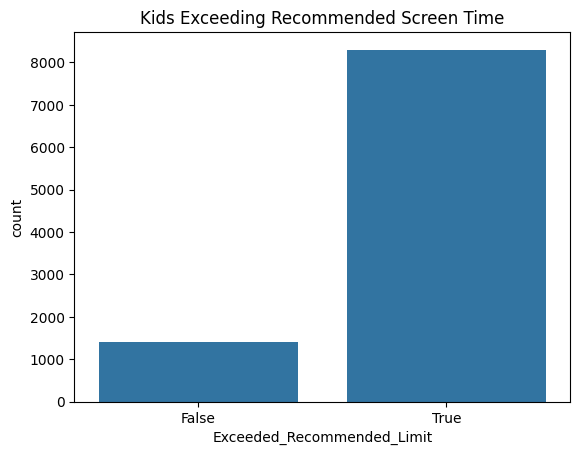

In [16]:
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title("Kids Exceeding Recommended Screen Time")
plt.show()


7. Correlation heatmap

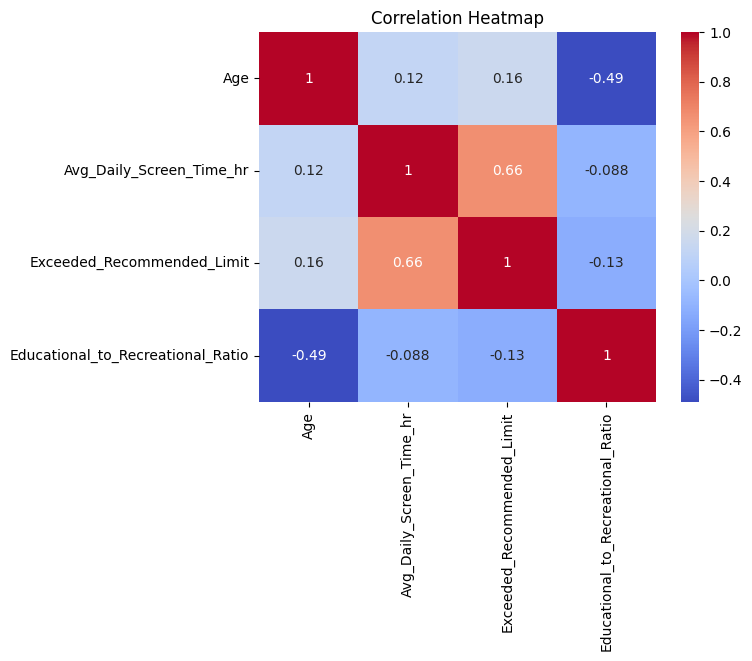

In [17]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [18]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural', 'Age_Group'],
      dtype='str')

In [19]:
df.dtypes

Age                                     int64
Gender                                    str
Avg_Daily_Screen_Time_hr              float64
Primary_Device                            str
Exceeded_Recommended_Limit               bool
Educational_to_Recreational_Ratio     float64
Health_Impacts                            str
Urban_or_Rural                            str
Age_Group                            category
dtype: object

In [20]:
df.shape

(9712, 9)

In [21]:
df['Exceeded_Recommended_Limit'].dtype

dtype('bool')

In [22]:
df['Exceeded_Recommended_Limit'] = df['Exceeded_Recommended_Limit'].map({True: "Yes", False: "No"})

In [23]:
df['Exceeded_Recommended_Limit'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [24]:
df['Gender'] = df['Gender'].str.strip().str.title()
df['Primary_Device'] = df['Primary_Device'].str.strip().str.title()
df['Urban_or_Rural'] = df['Urban_or_Rural'].str.strip().str.title()
df['Health_Impacts'] = df['Health_Impacts'].str.strip().str.title()

Derived Fields

In [25]:
bins = [6, 10, 14, 17]
labels = ['6-10', '11-14', '15-17']

df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels)

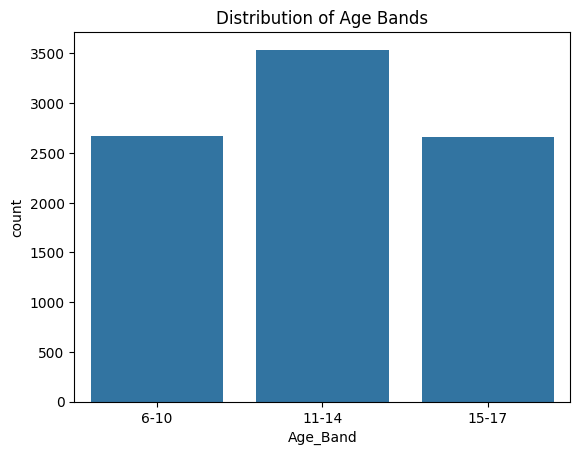

In [26]:
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Age Bands")
plt.show()

In [27]:
df['Educational_to_Recreational_Ratio'].describe()

count    9712.000000
mean        0.427226
std         0.073221
min         0.300000
25%         0.370000
50%         0.430000
75%         0.480000
max         0.600000
Name: Educational_to_Recreational_Ratio, dtype: float64

In [28]:
df['Educational_to_Recreational_Ratio'].max()

np.float64(0.6)

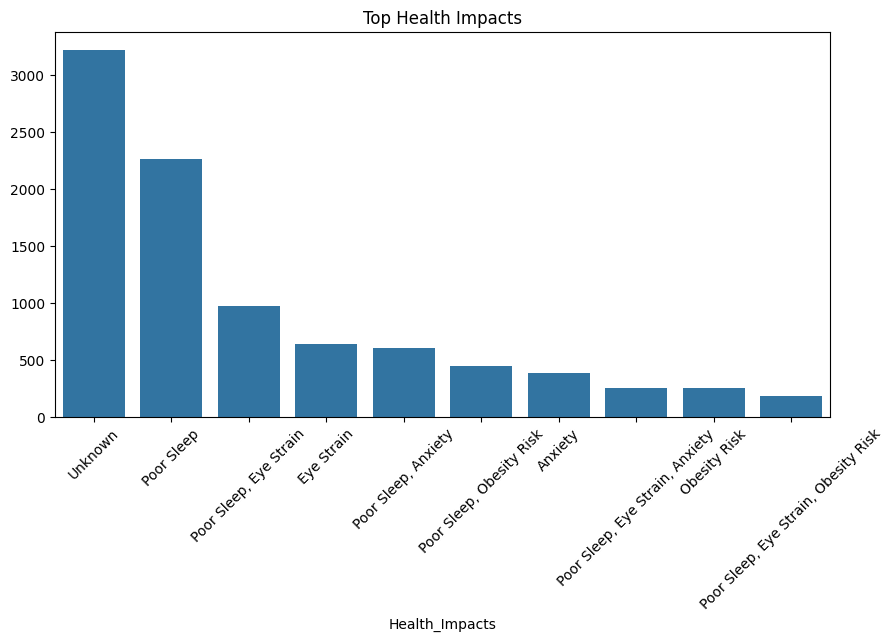

In [29]:
health_counts = df['Health_Impacts'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=health_counts.index, y=health_counts.values)
plt.xticks(rotation=45)
plt.title("Top Health Impacts")
plt.show()

In [30]:
# Age Band
df['Age_Band'] = pd.cut(df['Age'],
                        bins=[5,9,12,15,18],
                        labels=['6-9','10-12','13-15','16-18'])

# Usage Level
df['Usage_Level'] = pd.cut(df['Avg_Daily_Screen_Time_hr'],
                           bins=[0,2,4,6,10],
                           labels=['Low','Moderate','High','Extreme'])

# Device Type Category
df['Device_Type_Category'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in ['Mobile','Tablet','Laptop'] else 'Wall-Mounted'
)

In [31]:
df['Usage_Level'] = pd.cut(
    df['Educational_to_Recreational_Ratio'],
    bins=[0.3, 0.4, 0.5, 0.6],
    labels=['Low Educational', 'Moderate Educational', 'High Educational']
)


In [32]:
df['Usage_Level'].value_counts(normalize=True) * 100

Usage_Level
Moderate Educational    48.331234
Low Educational         38.192695
High Educational        13.476071
Name: proportion, dtype: float64

In [33]:
df['Educational_to_Recreational_Ratio'].describe()

count    9712.000000
mean        0.427226
std         0.073221
min         0.300000
25%         0.370000
50%         0.430000
75%         0.480000
max         0.600000
Name: Educational_to_Recreational_Ratio, dtype: float64

In [34]:
device_share = df['Primary_Device'].value_counts(normalize=True) * 100
print(device_share) # device share

Primary_Device
Smartphone    47.034596
Tv            25.607496
Laptop        14.754942
Tablet        12.602965
Name: proportion, dtype: float64


In [35]:
# Create Screen Time Category
df['Screen_Time_Category'] = pd.cut(
    df['Avg_Daily_Screen_Time_hr'],
    bins=[0,2,4,10],
    labels=['Low (0-2h)','Moderate (2-4h)','High (4h+)']
)
df[['Avg_Daily_Screen_Time_hr','Screen_Time_Category']].head()

,Avg_Daily_Screen_Time_hr,Screen_Time_Category
0,3.99,Moderate (2-4h)
1,4.61,High (4h+)
2,3.73,Moderate (2-4h)
3,1.21,Low (0-2h)
4,5.89,High (4h+)


# Univariant and Bivariant Analysis

#univariant

1.Age (Numerical)

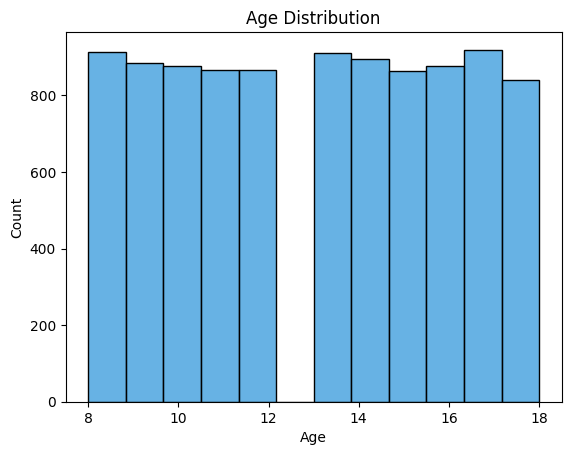

In [36]:
#histogram (univariant)
sns.histplot(df['Age'], bins=12, color='#3498db')
plt.title("Age Distribution")
plt.show()

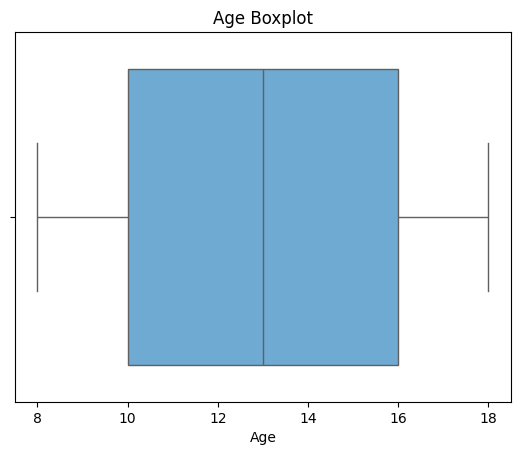

In [37]:
#boxplot
sns.boxplot(x=df['Age'], color='#5dade2')
plt.title("Age Boxplot")
plt.show()

#Bivariant

#Age vs Screen Time (Numerical vs Numerical)

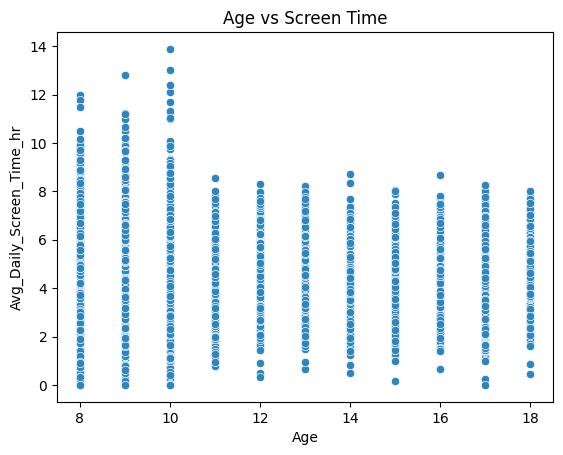

In [38]:
sns.scatterplot(x='Age',
                y='Avg_Daily_Screen_Time_hr',
                data=df,
                color='#2e86c1')
plt.title("Age vs Screen Time")
plt.show()

2.Gender (Categorical)

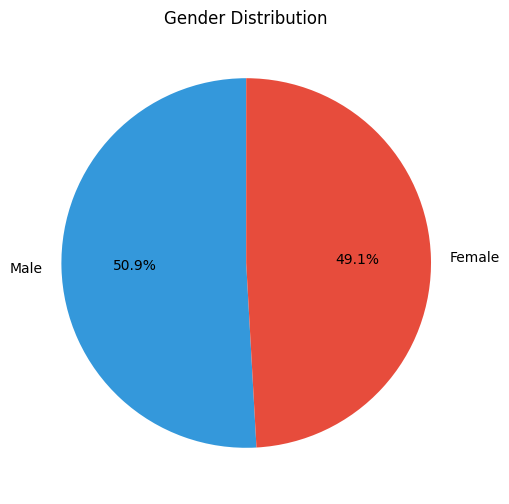

In [39]:
#univariant
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90)
plt.title("Gender Distribution")
plt.show()

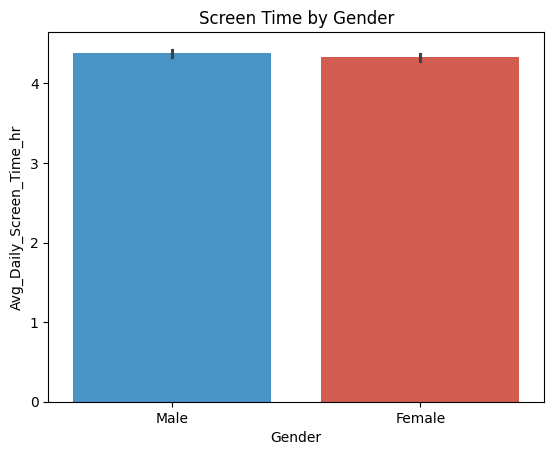

In [40]:
#Gender vs screen time (Bivariant)
sns.barplot(x='Gender',
            y='Avg_Daily_Screen_Time_hr',
            data=df,
            hue='Gender',
            palette=['#3498db', '#e74c3c'],
            legend=False)
plt.title("Screen Time by Gender")
plt.show()


3.Avg_Daily_Screen_Time_hr (Numerical)

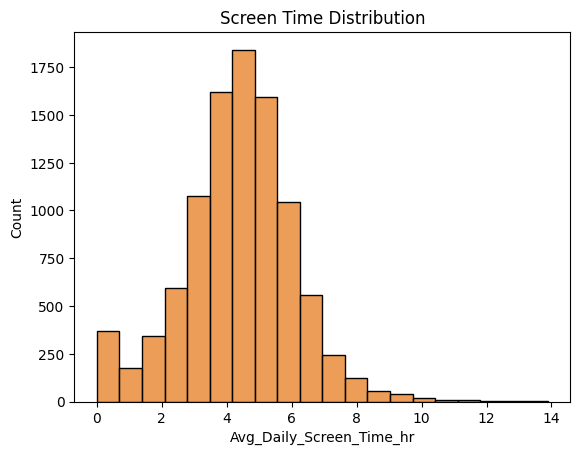

In [41]:
#univariant
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, color='#e67e22')
plt.title("Screen Time Distribution")
plt.show()

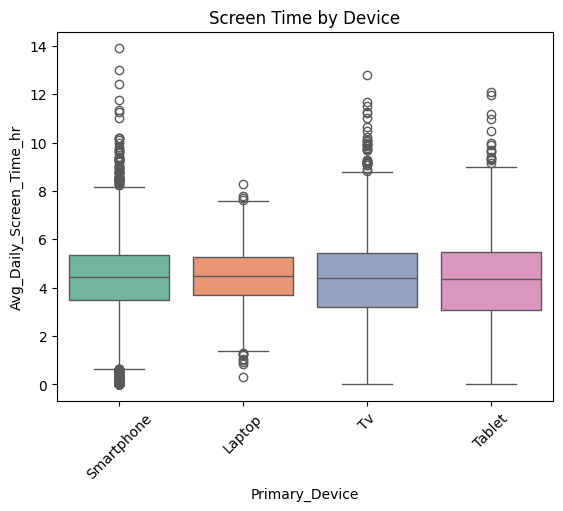

In [42]:
#screen time vs device (Bivariant)
sns.boxplot(
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    hue='Primary_Device',      
    data=df,
    palette='Set2',
    legend=False               
)

plt.xticks(rotation=45)
plt.title("Screen Time by Device")
plt.show()

4.Primary_Device (Categorical)

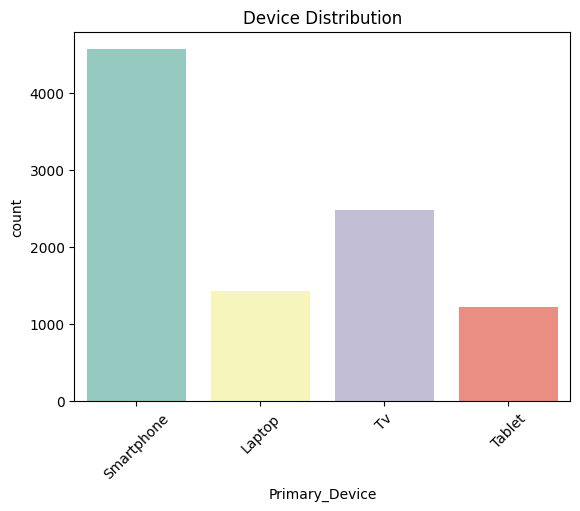

In [43]:
#univariant
sns.countplot(
    x='Primary_Device',
    hue='Primary_Device',   
    data=df,
    palette='Set3',
    legend=False           
)

plt.xticks(rotation=45)
plt.title("Device Distribution")
plt.show()

In [44]:
#device vs exceed limit (Bivariant)
pd.crosstab(df['Primary_Device'],
            df['Exceeded_Recommended_Limit'])

Exceeded_Recommended_Limit,No,Yes
Primary_Device,,
Laptop,158,1275
Smartphone,619,3949
Tablet,232,992
Tv,402,2085


5.Educational_to_Recreational_Ratio (Numerical)

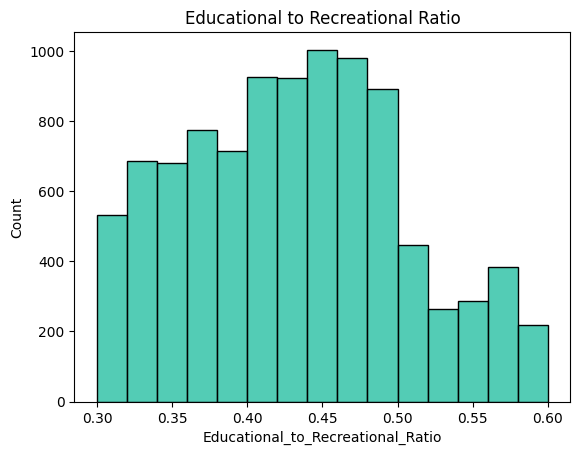

In [45]:
#univariant
sns.histplot(df['Educational_to_Recreational_Ratio'],
             bins=15,
             color='#1abc9c')
plt.title("Educational to Recreational Ratio")
plt.show()

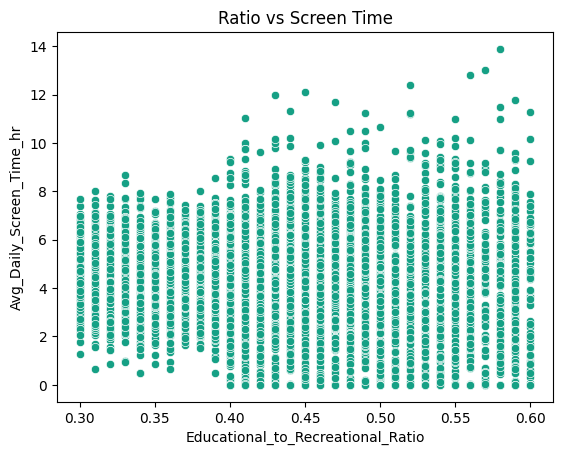

In [46]:
#ratio vs screen time (bivariant)
sns.scatterplot(x='Educational_to_Recreational_Ratio',
                y='Avg_Daily_Screen_Time_hr',
                data=df,
                color='#16a085')
plt.title("Ratio vs Screen Time")
plt.show()

6.Exceeded_Recommended_Limit (Categorical / Boolean)

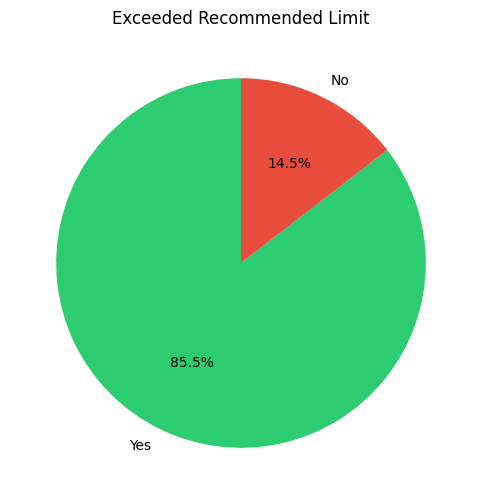

In [47]:
#univariant
limit_counts = df['Exceeded_Recommended_Limit'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(limit_counts,
        labels=limit_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90)
plt.title("Exceeded Recommended Limit")
plt.show()

Exceeded Limit vs Device Category

7.Health_Impacts (Categorical)

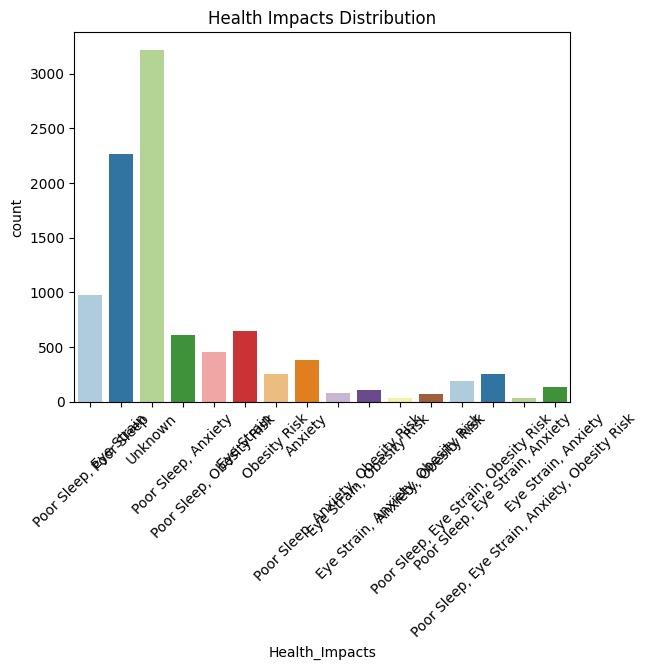

In [48]:
#univariant
sns.countplot(
    x='Health_Impacts',
    hue='Health_Impacts',   # required when using palette
    data=df,
    palette='Paired',
    legend=False            # removes duplicate legend
)

plt.xticks(rotation=45)
plt.title("Health Impacts Distribution")
plt.show()

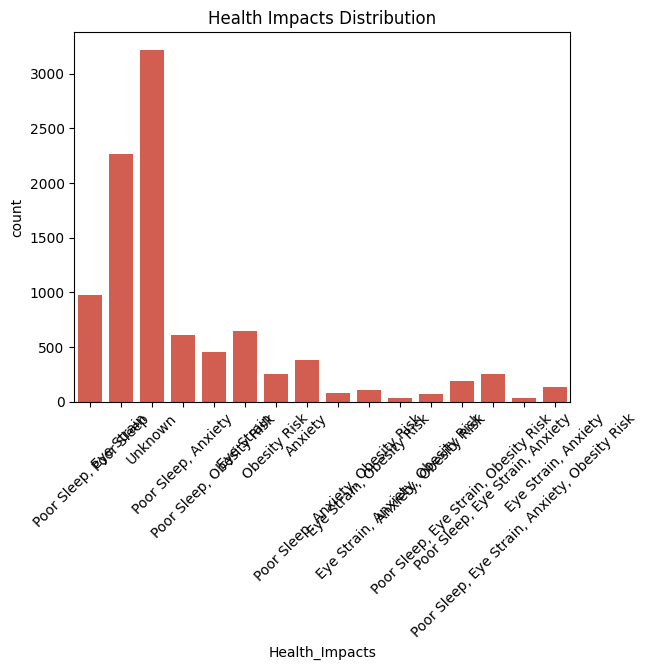

In [49]:
#Health Impact vs Screen Time (bivariant)
sns.countplot(
    x='Health_Impacts',
    data=df,
    color='#e74c3c'
)

plt.xticks(rotation=45)
plt.title("Health Impacts Distribution")
plt.show()

8.Urban_or_Rural (Categorical)

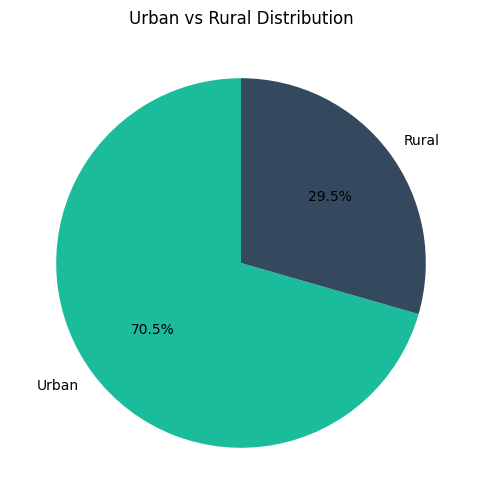

In [50]:
location_counts = df['Urban_or_Rural'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(location_counts,
        labels=location_counts.index,
        autopct='%1.1f%%',
        colors=['#1abc9c', '#34495e'],
        startangle=90)
plt.title("Urban vs Rural Distribution")
plt.show() #univariant

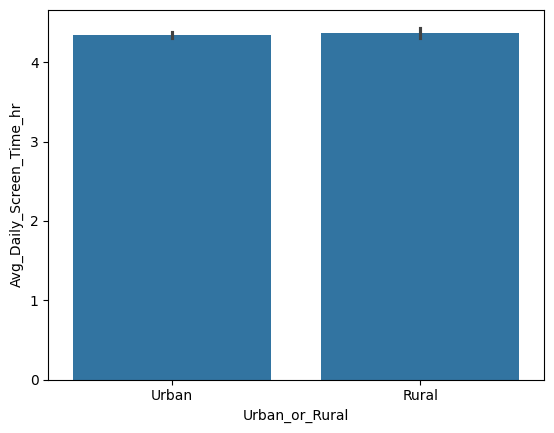

In [51]:
sns.barplot(x='Urban_or_Rural',
            y='Avg_Daily_Screen_Time_hr',
            data=df)
plt.show() #location vs screen time (bivariant)

Derived Columns

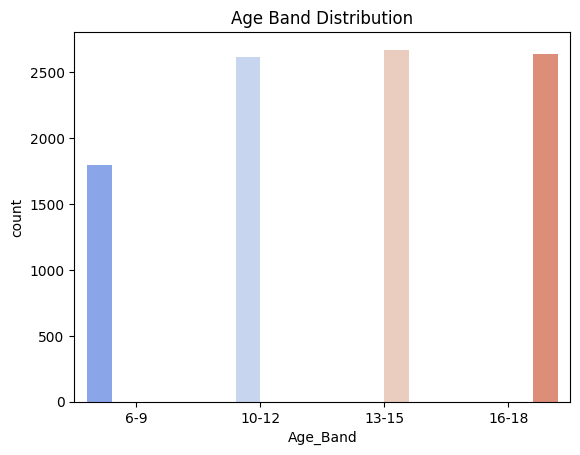

In [52]:
#Age_Band (Categorical)
sns.countplot(
    x='Age_Band',
    hue='Age_Band',      
    data=df,
    palette='coolwarm',
    legend=False         
)

plt.title("Age Band Distribution")
plt.show()

In [53]:
df.columns


Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural', 'Age_Group', 'Age_Band',
       'Usage_Level', 'Device_Type_Category', 'Screen_Time_Category'],
      dtype='str')

In [54]:
df['Device_Type_Category'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in ['Mobile', 'Tablet', 'Laptop'] else 'Wall-Mounted'
)

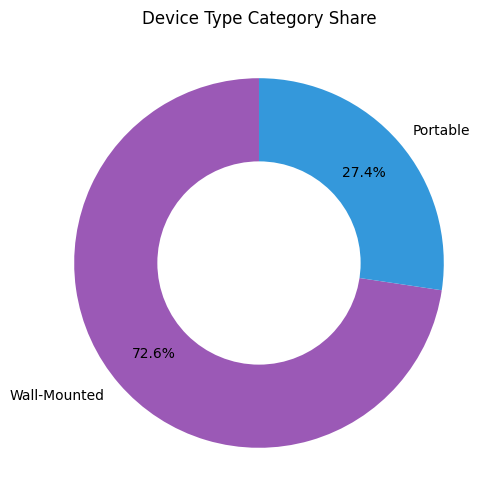

In [55]:
#Device_Type_Category
device_counts = df['Device_Type_Category'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(device_counts,
        labels=device_counts.index,
        autopct='%1.1f%%',
        pctdistance=0.75,   # moves percentage outward
        colors=['#9b59b6', '#3498db'],
        startangle=90)

# create donut hole
centre_circle = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Device Type Category Share")

plt.show()

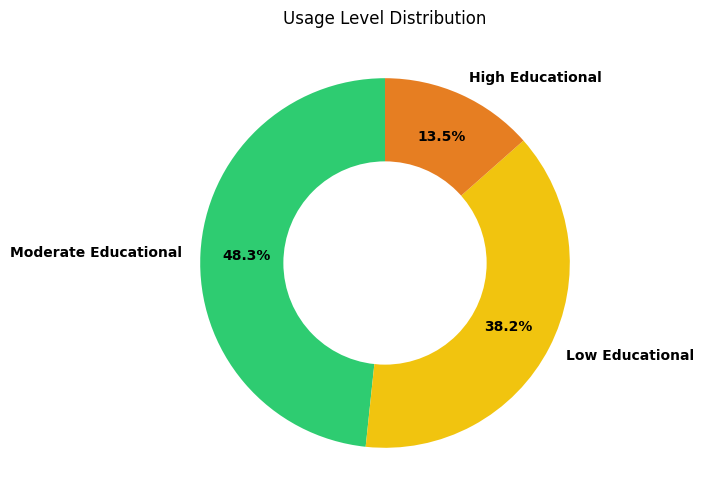

In [56]:
#Usage level
usage_counts = df['Usage_Level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    usage_counts,
    labels=usage_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.75,  # moves percentage text outward
    colors=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
    startangle=90,
    textprops={'weight':'bold'}
)

# Create donut hole
centre_circle = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Usage Level Distribution")

plt.show()

# Univariant visual analysis

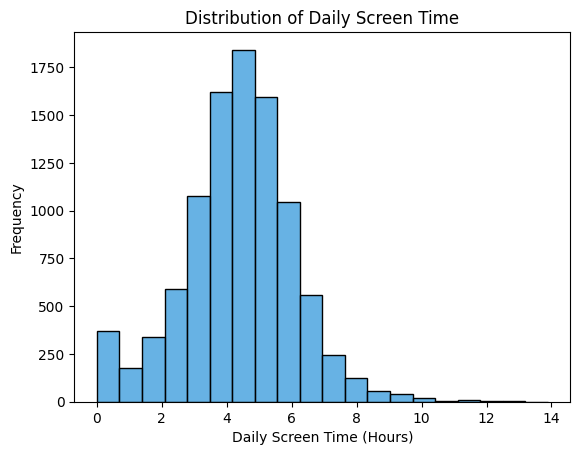

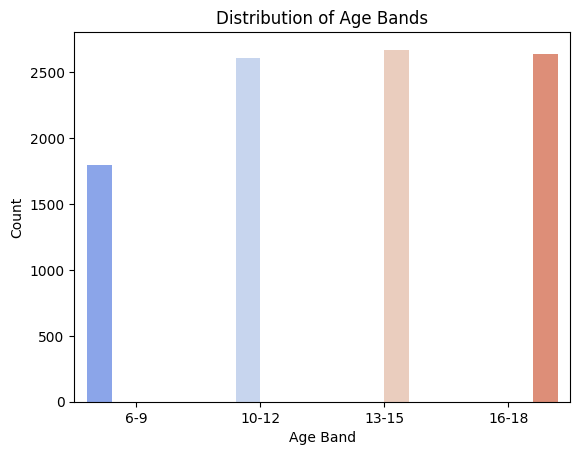

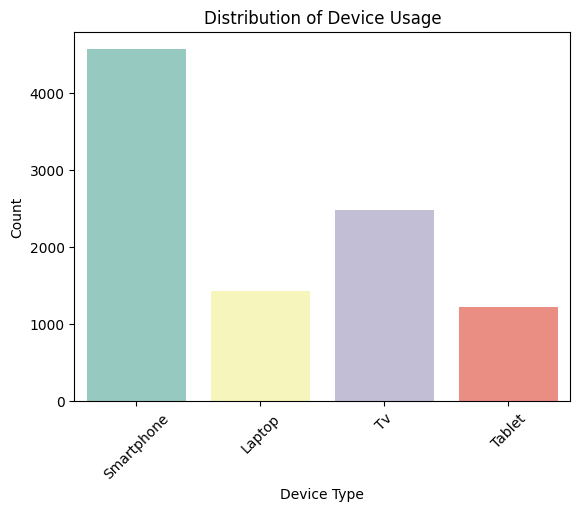

In [57]:
# Distribution of Daily Screen Time
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, color='#3498db')
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()


# Distribution of Age Bands
sns.countplot(
    x='Age_Band',
    hue='Age_Band',
    data=df,
    palette='coolwarm',
    legend=False
)
plt.title("Distribution of Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()


# Distribution of Device Usage
sns.countplot(
    x='Primary_Device',
    hue='Primary_Device',
    data=df,
    palette='Set3',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Distribution of Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

# Bivariant visual analysis

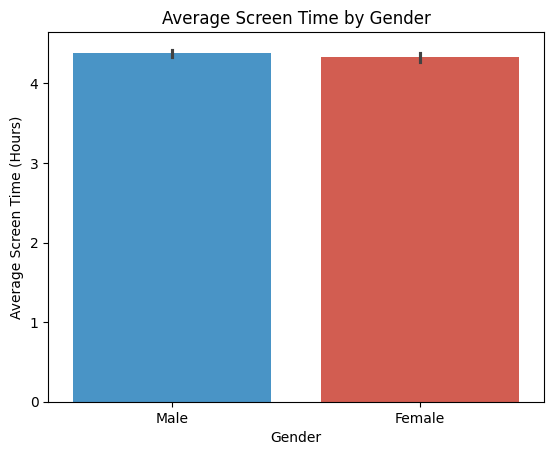

In [58]:
#Screen Time by Gender (Bar Chart)
sns.barplot(
    x='Gender',
    y='Avg_Daily_Screen_Time_hr',
    hue='Gender',
    data=df,
    palette=['#3498db','#e74c3c'],
    legend=False
)

plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

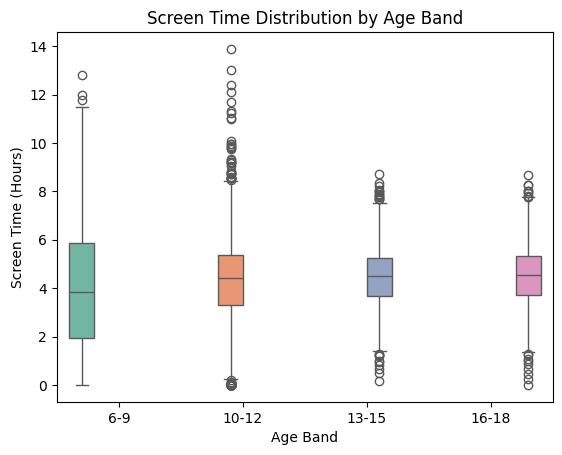

In [59]:
#Screen Time by Age Band
sns.boxplot(
    x='Age_Band',
    y='Avg_Daily_Screen_Time_hr',
    hue='Age_Band',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Screen Time Distribution by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Screen Time (Hours)")
plt.show()

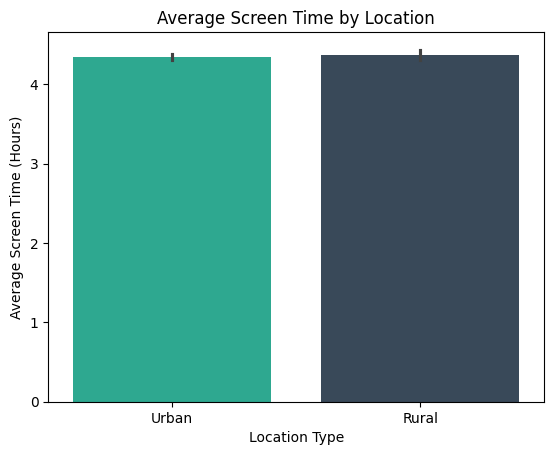

In [60]:
# screen time by location (urban vs rural)
sns.barplot(
    x='Urban_or_Rural',
    y='Avg_Daily_Screen_Time_hr',
    hue='Urban_or_Rural',
    data=df,
    palette=['#1abc9c','#34495e'],
    legend=False
)

plt.title("Average Screen Time by Location")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

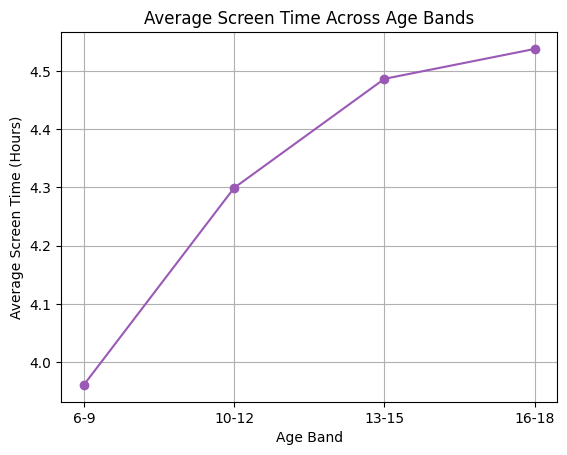

In [61]:
#Screen Time Trend Across Age Bands (Line Plot)
avg_screen_age = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()

plt.plot(avg_screen_age.index, avg_screen_age.values, marker='o', color='#9b59b6')

plt.title("Average Screen Time Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(True)
plt.show()

Device Mix by Gender

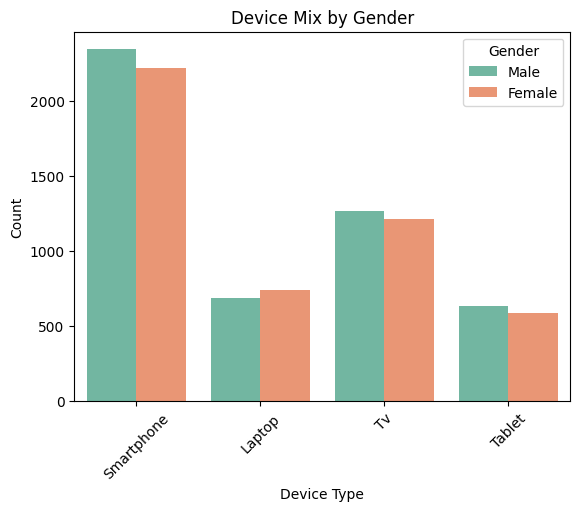

In [62]:
sns.countplot(
    x='Primary_Device',
    hue='Gender',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Device Mix by Gender")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

Device Mix by Age Band

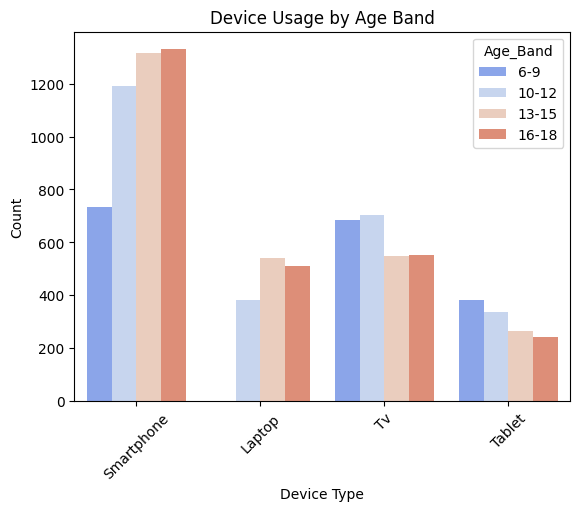

In [63]:
sns.countplot(
    x='Primary_Device',
    hue='Age_Band',
    data=df,
    palette='coolwarm'
)

plt.xticks(rotation=45)
plt.title("Device Usage by Age Band")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

Screen Time by Device Type

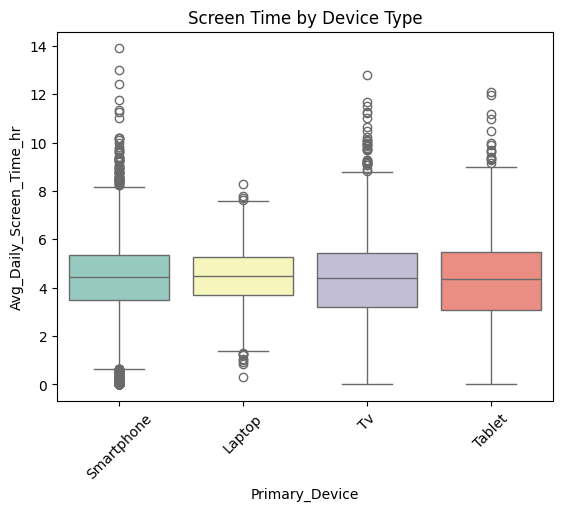

In [64]:
sns.boxplot(
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    hue='Primary_Device',
    data=df,
    palette='Set3',
    legend=False
)

plt.xticks(rotation=45)
plt.title("Screen Time by Device Type")
plt.show()

Activity Category vs Screen Time

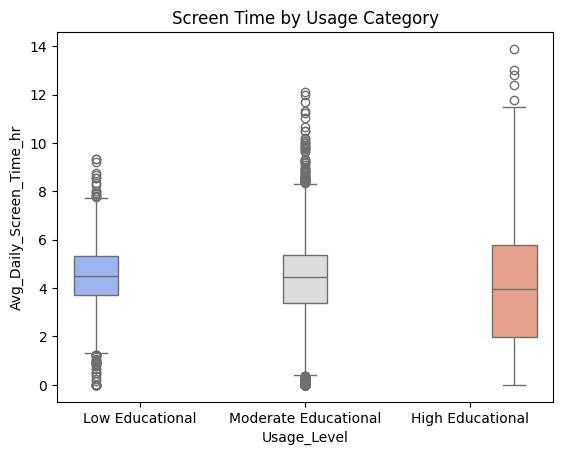

In [65]:
sns.boxplot(
    x='Usage_Level',
    y='Avg_Daily_Screen_Time_hr',
    hue='Usage_Level',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title("Screen Time by Usage Category")
plt.show()

Screen Time Trend by Age Band (Line Plot)

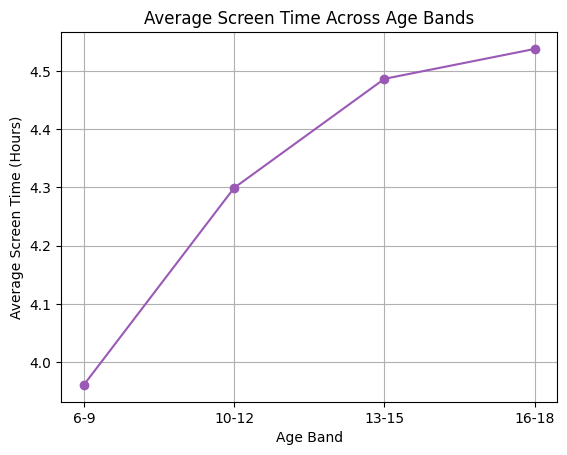

In [66]:
avg_age_screen = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()

plt.plot(avg_age_screen.index, avg_age_screen.values, marker='o', color='#9b59b6')

plt.title("Average Screen Time Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(True)
plt.show()

Device Category vs Exceeded Limit

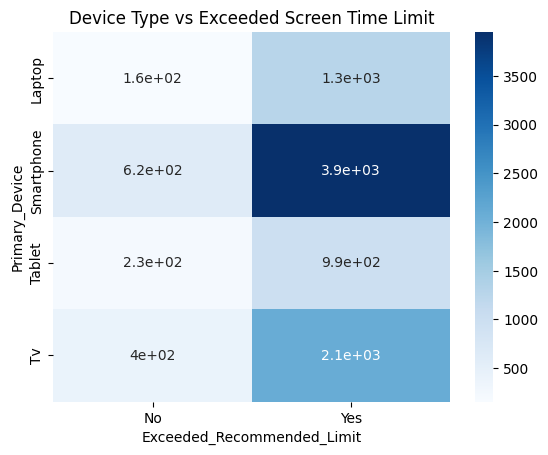

In [67]:
ct = pd.crosstab(df['Primary_Device'],
                 df['Exceeded_Recommended_Limit'])

sns.heatmap(ct, annot=True, cmap='Blues')

plt.title("Device Type vs Exceeded Screen Time Limit")
plt.show()

Age Band vs Usage Level

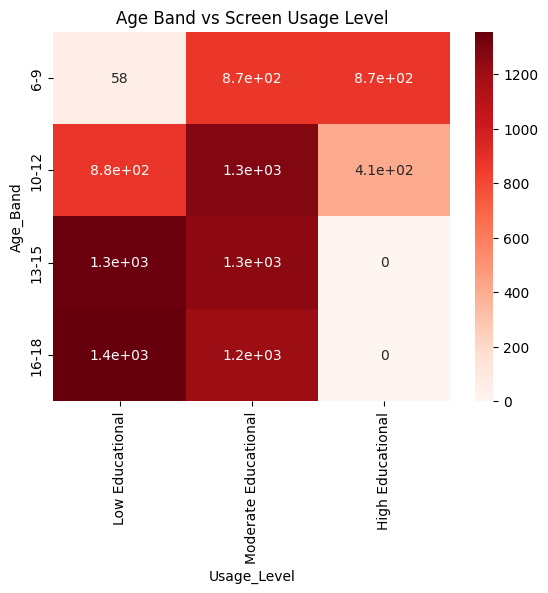

In [68]:
ct2 = pd.crosstab(df['Age_Band'],
                  df['Usage_Level'])

sns.heatmap(ct2, annot=True, cmap='Reds')

plt.title("Age Band vs Screen Usage Level")
plt.show()

# Cohort Analysis

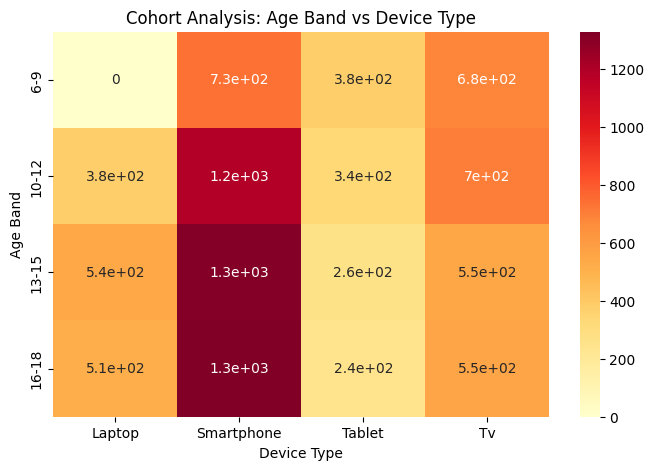

In [69]:
#Age Band × Device Type
cohort_table = pd.crosstab(
    df['Age_Band'],
    df['Primary_Device']
)

plt.figure(figsize=(8,5))

sns.heatmap(cohort_table,
            annot=True,
            cmap="YlOrRd")

plt.title("Cohort Analysis: Age Band vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()

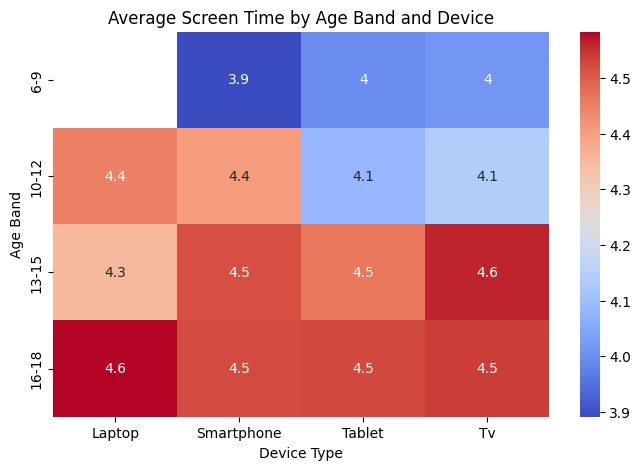

In [70]:
#Average Screen Time by Age Band × Device
cohort_screen = df.groupby(
    ['Age_Band','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(8,5))

sns.heatmap(cohort_screen,
            annot=True,
            cmap="coolwarm")

plt.title("Average Screen Time by Age Band and Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()


# Segment Analysis

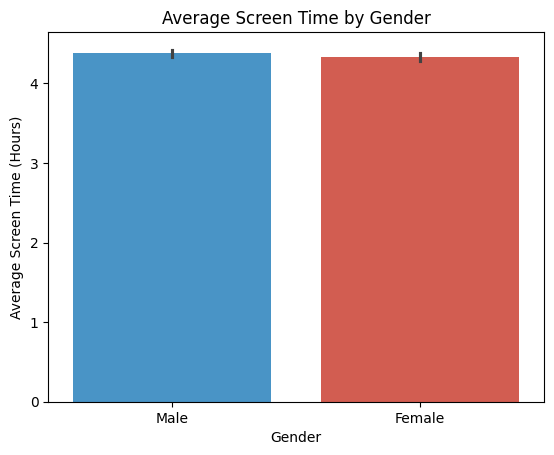

In [71]:
#Screen Time by Gender
sns.barplot(
    x='Gender',
    y='Avg_Daily_Screen_Time_hr',
    hue='Gender',
    data=df,
    palette=['#3498db','#e74c3c'],
    legend=False
)

plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

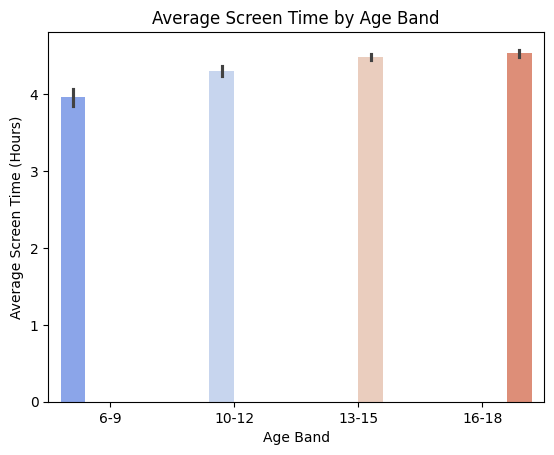

In [72]:
#screen time by age band
sns.barplot(
    x='Age_Band',
    y='Avg_Daily_Screen_Time_hr',
    hue='Age_Band',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

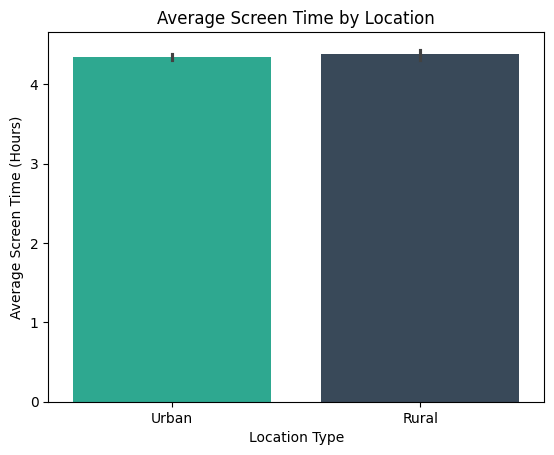

In [73]:
# screen time by location
sns.barplot(
    x='Urban_or_Rural',
    y='Avg_Daily_Screen_Time_hr',
    hue='Urban_or_Rural',
    data=df,
    palette=['#1abc9c','#34495e'],
    legend=False
)

plt.title("Average Screen Time by Location")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

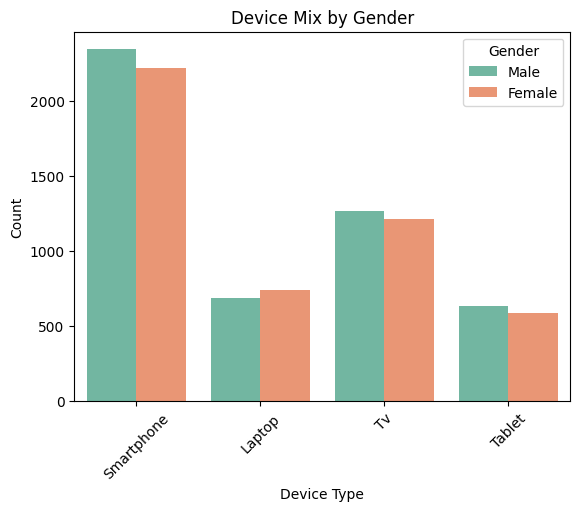

In [74]:
# Device Mix by Gender
sns.countplot(
    x='Primary_Device',
    hue='Gender',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Device Mix by Gender")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

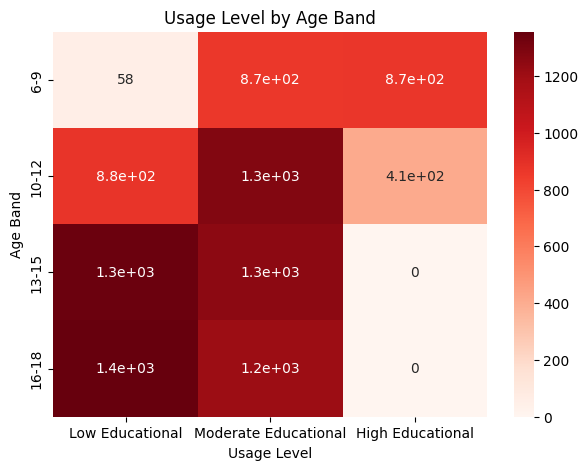

In [75]:
# Usage level by age band
usage_age = pd.crosstab(df['Age_Band'], df['Usage_Level'])

plt.figure(figsize=(7,5))

sns.heatmap(usage_age,
            annot=True,
            cmap='Reds')

plt.title("Usage Level by Age Band")
plt.xlabel("Usage Level")
plt.ylabel("Age Band")

plt.show()

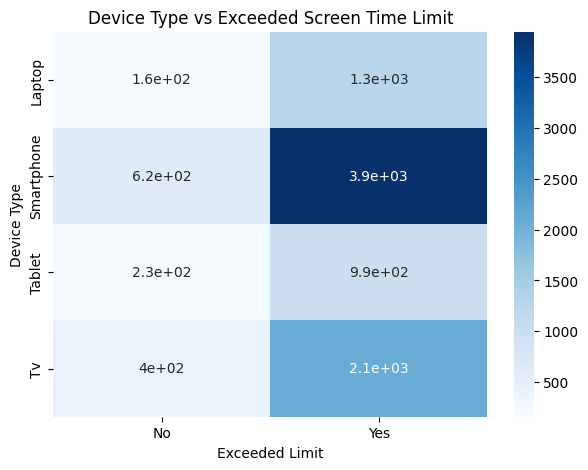

In [76]:
# Device type vs exceeds screen time limit
limit_device = pd.crosstab(df['Primary_Device'],
                           df['Exceeded_Recommended_Limit'])

plt.figure(figsize=(7,5))

sns.heatmap(limit_device,
            annot=True,
            cmap='Blues')

plt.title("Device Type vs Exceeded Screen Time Limit")
plt.xlabel("Exceeded Limit")
plt.ylabel("Device Type")

plt.show()

Habit Pattern Analysis (Age Behavior)

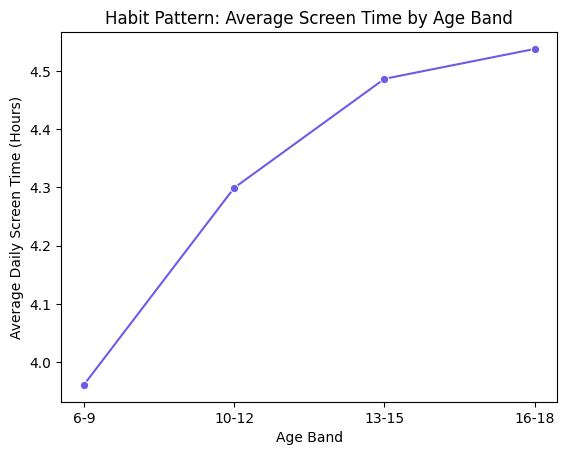

In [77]:
age_pattern = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

sns.lineplot(
    data=age_pattern,
    x='Age_Band',
    y='Avg_Daily_Screen_Time_hr',
    marker='o',
    color='#6c5ce7'
)

plt.title("Habit Pattern: Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

Device Habit Pattern

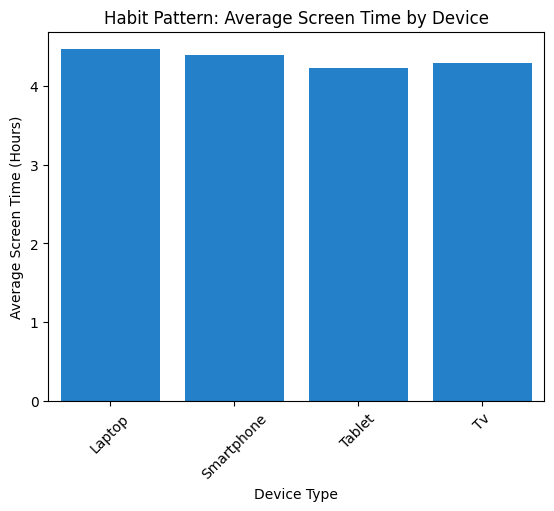

In [78]:
device_pattern = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

sns.barplot(
    data=device_pattern,
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    color='#0984e3'
)

plt.xticks(rotation=45)
plt.title("Habit Pattern: Average Screen Time by Device")
plt.xlabel("Device Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Location Habit Pattern

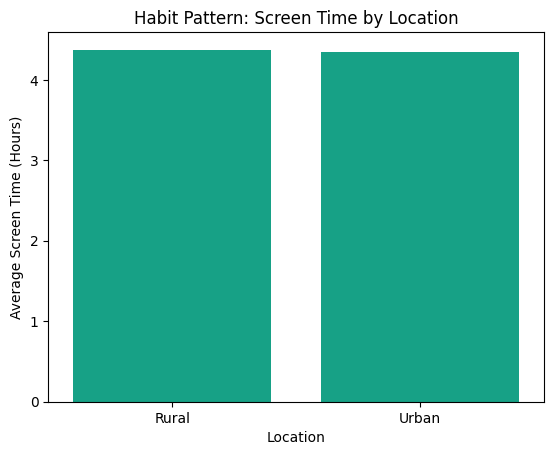

In [79]:
location_pattern = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

sns.barplot(
    data=location_pattern,
    x='Urban_or_Rural',
    y='Avg_Daily_Screen_Time_hr',
    color='#00b894'
)

plt.title("Habit Pattern: Screen Time by Location")
plt.xlabel("Location")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Cohort Analysis (Age × Device)

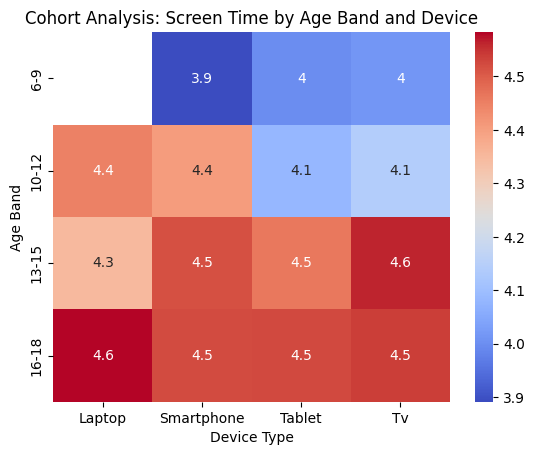

In [80]:
cohort_data = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

sns.heatmap(
    cohort_data,
    annot=True,
    cmap='coolwarm'
)

plt.title("Cohort Analysis: Screen Time by Age Band and Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

Segment Analysis (Gender × Screen Time)

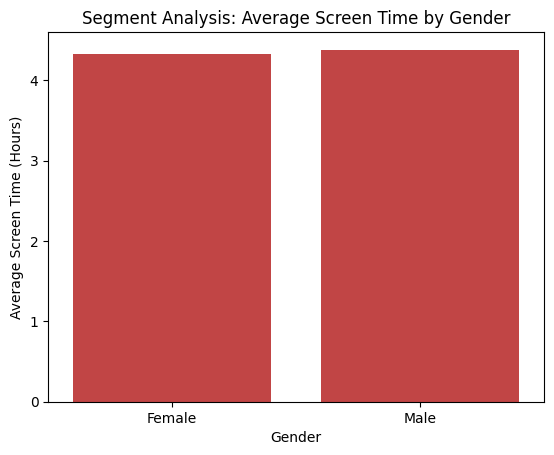

In [81]:
gender_pattern = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

sns.barplot(
    data=gender_pattern,
    x='Gender',
    y='Avg_Daily_Screen_Time_hr',
    color='#d63031'
)

plt.title("Segment Analysis: Average Screen Time by Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Segment Comparison (Age × Usage Level)

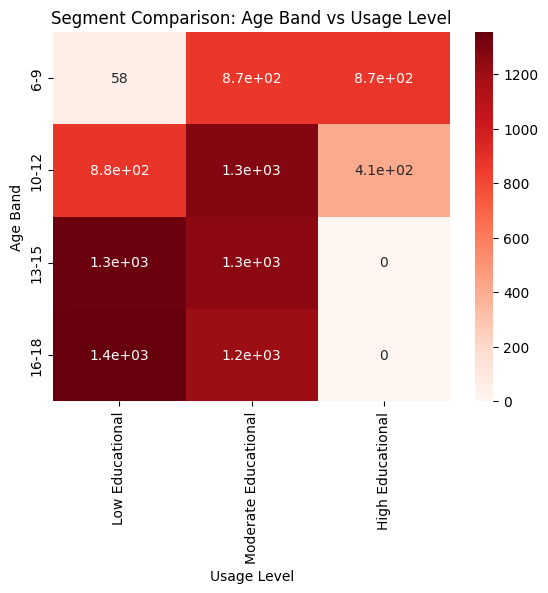

In [82]:
segment_table = pd.crosstab(df['Age_Band'], df['Usage_Level'])

sns.heatmap(
    segment_table,
    annot=True,
    cmap='Reds'
)

plt.title("Segment Comparison: Age Band vs Usage Level")
plt.xlabel("Usage Level")
plt.ylabel("Age Band")
plt.show()

Device Impact on Screen Time Distribution

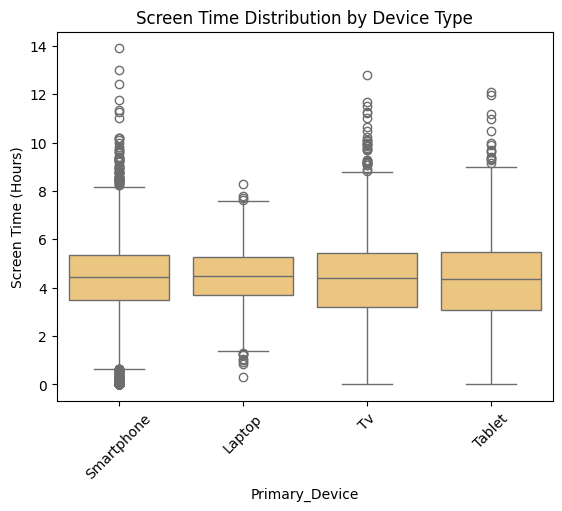

In [83]:
sns.boxplot(
    data=df,
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    color='#fdcb6e'
)

plt.xticks(rotation=45)
plt.title("Screen Time Distribution by Device Type")
plt.ylabel("Screen Time (Hours)")
plt.show()

Habit Driver Analysis

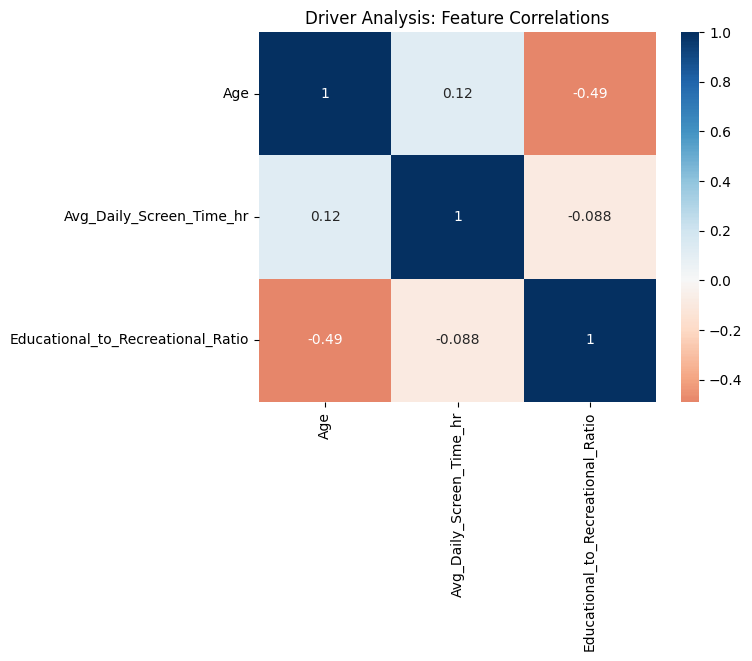

In [84]:
numeric_features = df[['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio']]

corr = numeric_features.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu',
    center=0
)

plt.title("Driver Analysis: Feature Correlations")
plt.show()

Screen Behavior Composition (Stacked Usage Profile)

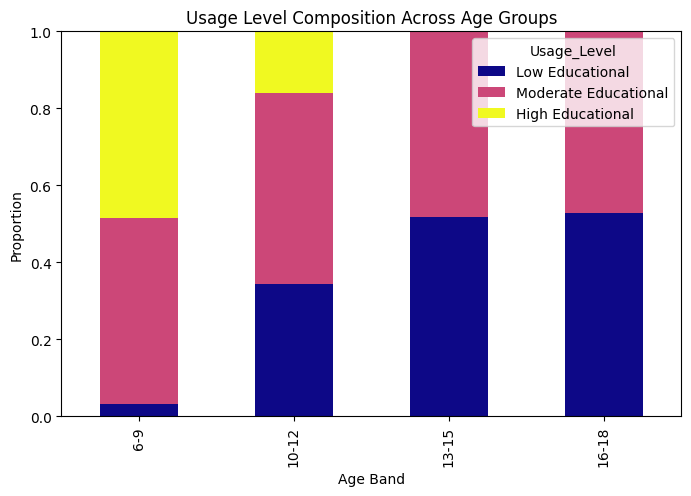

In [85]:
usage_profile = pd.crosstab(df['Age_Band'], df['Usage_Level'], normalize='index')

usage_profile.plot(
    kind='bar',
    stacked=True,
    colormap='plasma',
    figsize=(8,5)
)

plt.title("Usage Level Composition Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Proportion")

plt.show()

Behavioral Driver Scatter (Usage vs Learning Balance)

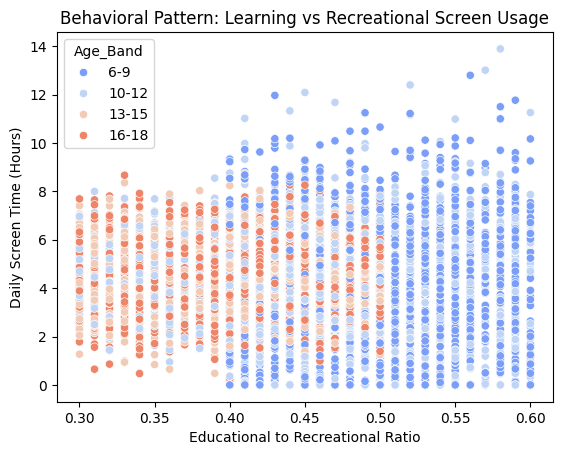

In [86]:
sns.scatterplot(
    data=df,
    x='Educational_to_Recreational_Ratio',
    y='Avg_Daily_Screen_Time_hr',
    hue='Age_Band',
    palette='coolwarm'
)

plt.title("Behavioral Pattern: Learning vs Recreational Screen Usage")
plt.xlabel("Educational to Recreational Ratio")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

Device vs Age Usage Matrix (Advanced Cohort View)

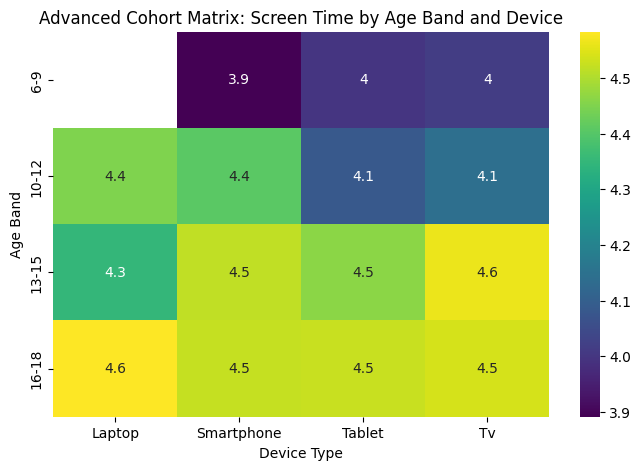

In [87]:
cohort_matrix = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cohort_matrix,
    annot=True,
    cmap='viridis'
)

plt.title("Advanced Cohort Matrix: Screen Time by Age Band and Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()

# Insights

Habit Pattern, Cohort and Segment Analysis Insights:

The habit pattern analysis indicates that screen time behavior is strongly influenced by age and device accessibility. Older children generally exhibit higher average screen time compared to younger age groups, suggesting increasing digital engagement as children grow older.

Device-based analysis reveals that portable devices such as mobile phones and tablets contribute significantly to higher screen exposure. These devices are more accessible and convenient, allowing children to use them more frequently throughout the day.

Location-based segment analysis shows that children living in urban areas tend to have slightly higher screen time compared to those in rural areas, likely due to better access to digital infrastructure and internet connectivity.

Cohort analysis combining age bands and device types highlights that older children using portable devices represent the highest screen usage groups. These cohorts form the peak usage segments in the dataset.

Usage level composition further indicates that higher age groups contain a larger proportion of moderate to high screen usage categories. This suggests that digital habits become more intensive with increasing age.

Additionally, behavioral analysis between educational and recreational screen usage suggests that recreational activities tend to drive longer screen exposure compared to educational usage.

Overall, the findings indicate that age, device portability, and accessibility are the primary drivers influencing screen time patterns among children.